# Trabajo Práctico 4 — Aprendizaje No-Supervisado
## Ejercicio 1: Inspección de los datos

---

**Dataset:**   
**Objetivo:** Explorar la naturaleza del dataset.

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enable autoreload for automatic updates of imported modules
%load_ext autoreload
%autoreload 2

# Add src folder to path
import sys, os
ruta_src = os.path.abspath("src")
sys.path.append(ruta_src)

import utils, data_splitting, models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
np.random.seed(42)

In [114]:
# load data frame
df = pd.read_csv('data/raw/fashion_mnist_subset.csv')

In [115]:
# separate features and label
y = df["label"].values
X = df.drop("label", axis=1).values

In [116]:
# dataset summary 
summary_data, summary_labels = utils.dataset_summary(X, y)

In [117]:
display(summary_data)

,Métrica,Valor
0,Samples,"25,000"
1,Features,784 (28x28 px)
2,Classes,10
3,Pixel range,"[0.0, 1.0]"
4,Dtype,float64
5,NaN values,0
6,Balance,uniform


In [118]:
display(summary_labels)

,Class ID,Name,Count,Pct (%)
0,0,T-shirt/top,2500,10.0
1,1,Trouser,2500,10.0
2,2,Pullover,2500,10.0
3,3,Dress,2500,10.0
4,4,Coat,2500,10.0
5,5,Sandal,2500,10.0
6,6,Shirt,2500,10.0
7,7,Sneaker,2500,10.0
8,8,Bag,2500,10.0
9,9,Ankle boot,2500,10.0


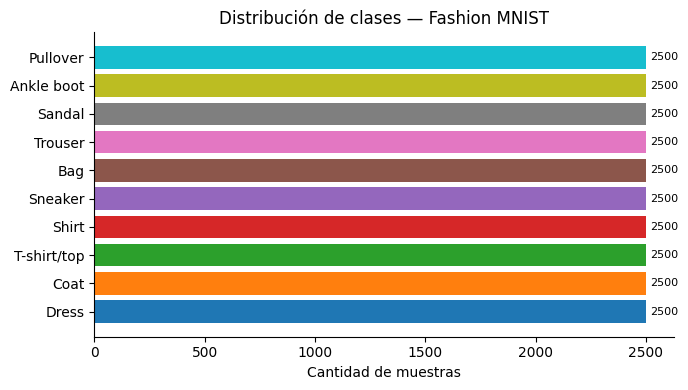

In [119]:
# show classes proportions
utils.show_proportions(df)

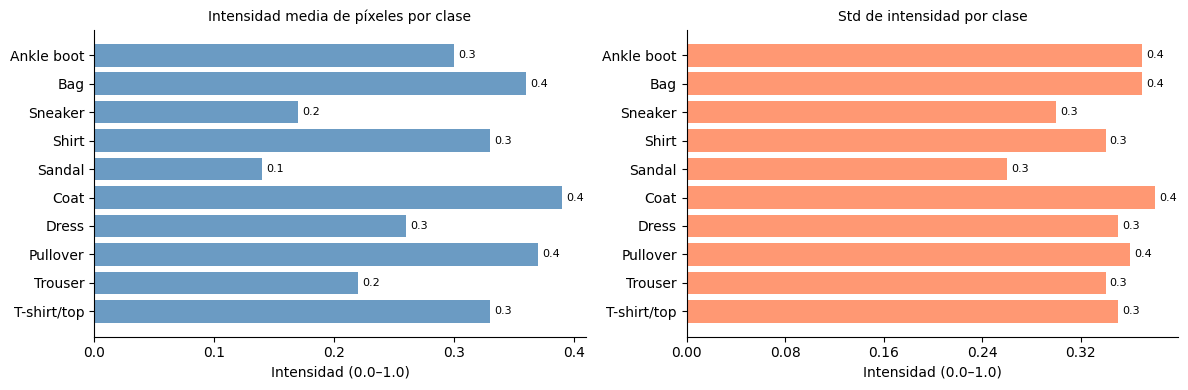

,class,mean_px,std_px
0,T-shirt/top,0.33,0.35
1,Trouser,0.22,0.34
2,Pullover,0.37,0.36
3,Dress,0.26,0.35
4,Coat,0.39,0.38
5,Sandal,0.14,0.26
6,Shirt,0.33,0.34
7,Sneaker,0.17,0.30
8,Bag,0.36,0.37
9,Ankle boot,0.30,0.37


In [120]:
pixel_stats = utils.analyze_pixels(X, y)
display(pixel_stats)

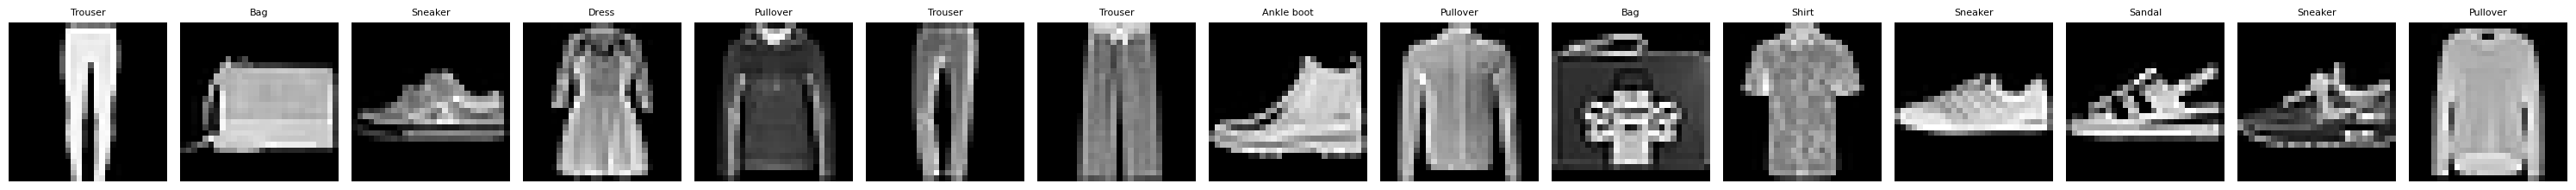

In [127]:
# show 15 random items
idx = utils.show_images(X, y, 15)

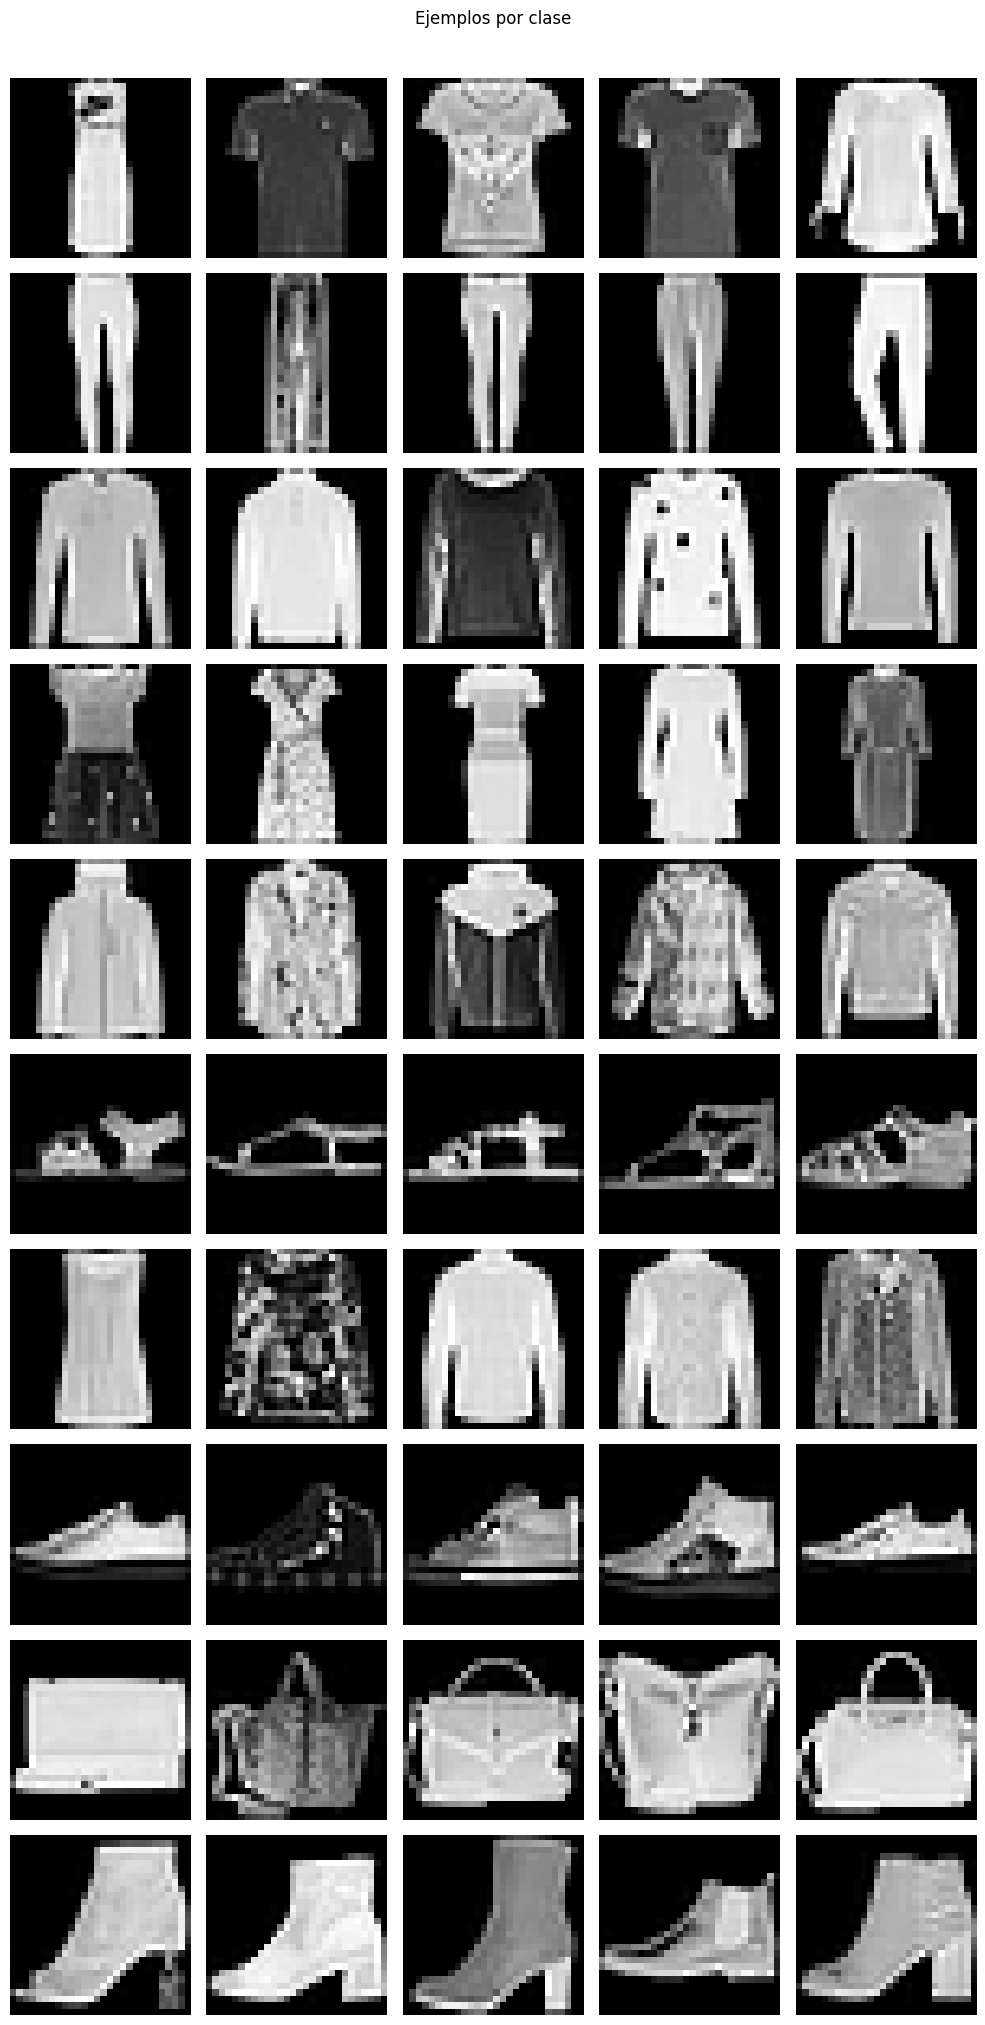

In [129]:
# show 5 items per class
utils.show_separate_classes(X, y, np.unique(y), 5)

In [123]:
# split data
train, test = data_splitting.random_stratified_split(df)

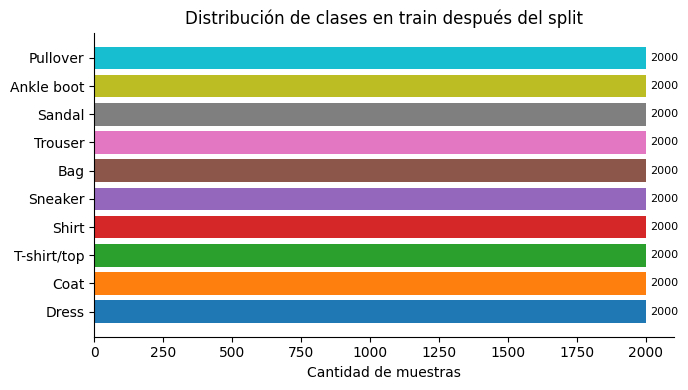

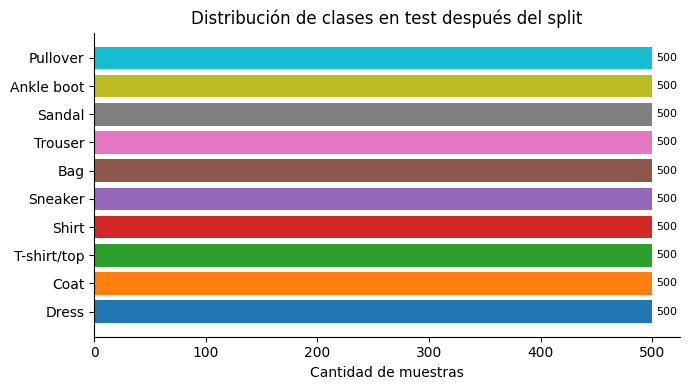

In [124]:
utils.show_proportions(train, title="Distribución de clases en train después del split")
utils.show_proportions(test, title="Distribución de clases en test después del split")

In [133]:
# separate features and label
y_train = train["label"].values
X_train = train.drop("label", axis=1)
y_test = test["label"].values
X_test = test.drop("label", axis=1)

## Ejercicio 2: Reducción de dimensionalidad

---

**Dataset:**   
**Objetivo:**

In [142]:
pca = models.PCA(k_components=784)

In [143]:
X_train_std = pca.fit_transform_scaler(X_train)
X_test_std = pca.transform_scaler(X_test)

_ = pca.fit_transform_pca(X_train_std)

Componentes para explicar 90% de varianza: 135


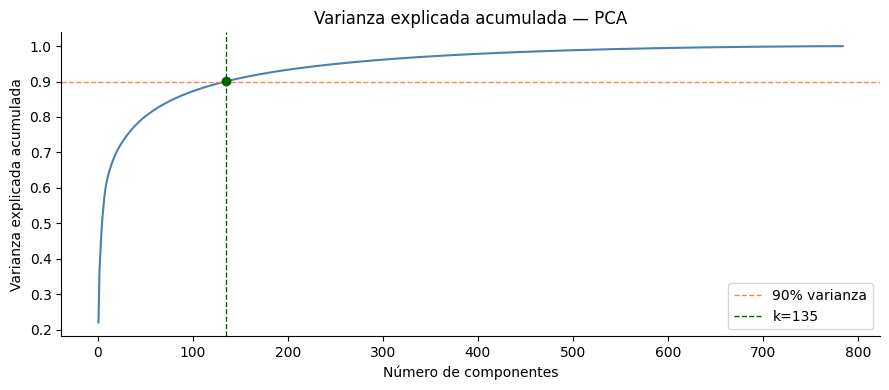

In [144]:
k_opt = utils.plot_explained_variance(pca)

In [145]:
pca_opt = models.PCA(k_components=k_opt)

In [146]:
X_train_std = pca.fit_transform_scaler(X_train)
X_test_std = pca.transform_scaler(X_test)

X_train_pca = pca.fit_transform_pca(X_train_std)
X_test_pca = pca.transform_pca(X_test_std)

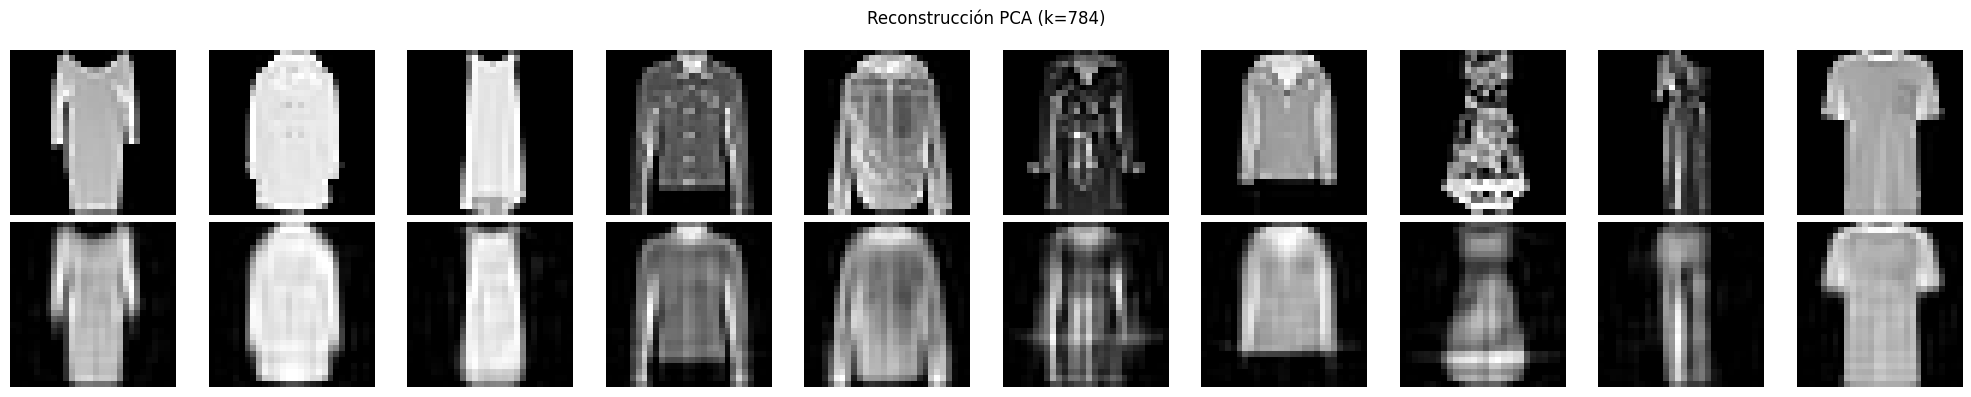

In [151]:
X_train_recon = utils.reconstruct(X_train_std, pca, k_opt)
# índices fijos — los mismos que usarás para el AE en 2d
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_train.values, X_train_recon, indices)

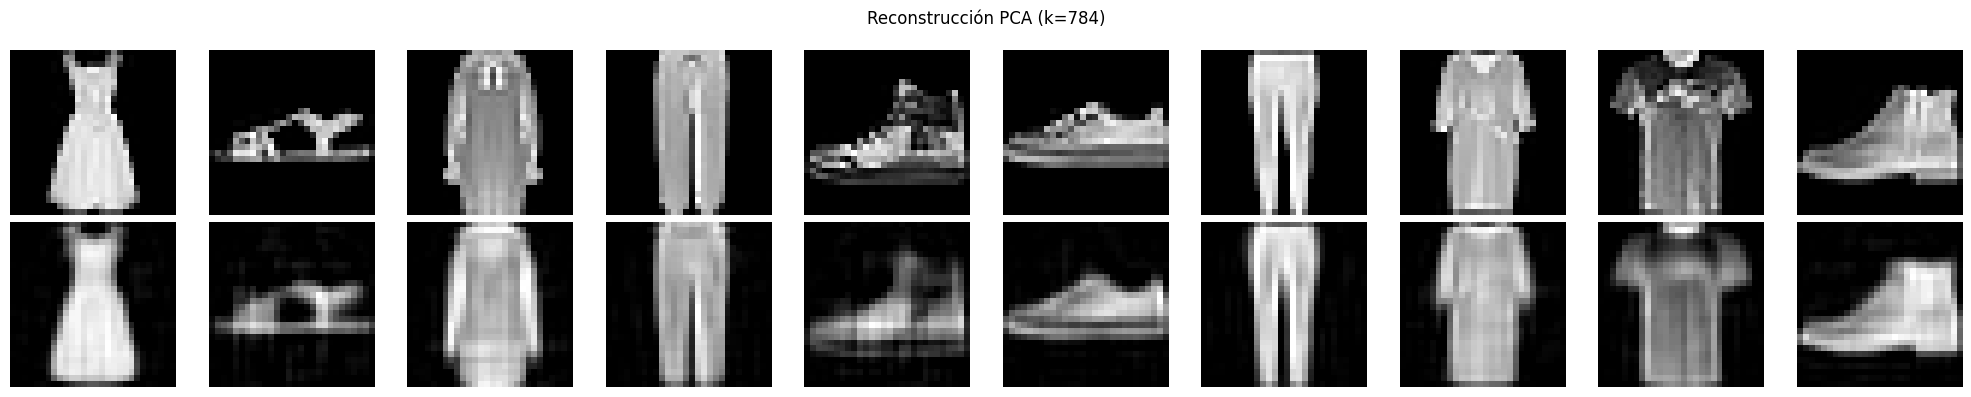

In [150]:
X_test_recon = utils.reconstruct(X_test_std, pca, k_opt)
# índices fijos — los mismos que usarás para el AE en 2d
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_test.values, X_test_recon, indices)